1. Load CSV Files

    Read all CSV files from the "Data" folder.
2. Select Data by Direction

    Filter and load data for one direction (R1 or R2) as needed.
3. Clean the Data

    Remove duplicates, irrelevant columns, and handle inconsistent entries.
4. Handle Missing Values

    Replace null values using appropriate methods (mean, median, mode, or custom logic).
5. Normalize the Data

    Scale features to a common range (e.g., MinMaxScaler).
6. Standardize the Data

    Transform features to have zero mean and unit variance (e.g., StandardScaler).
7. Merge Carline Data

    Combine all carline data into two datasets: one for R1 and one for R2.
8. Create Classes for Output

    Convert the output column (y) into categorical classes for classification.
9. Fit an ML Model

    Train a classification model (e.g., RandomForest, SVM, etc.).
10. Evaluate the Model

    Use confusion matrix and other metrics (accuracy, precision, recall, F1-score).
11. Improve Model Performance

    Apply techniques like feature selection, hyperparameter tuning, or ensemble methods.
12. Save the Model

    If performance is satisfactory, serialize the model using pickle.
13. Deploy with Flask

    Integrate the pickle model into a Flask backend for predictions.

In [ ]:
# Step 1: Load all CSV files from the "Data" folder

import os
import pandas as pd

data_folder = "../Data/01_clean"  # Adjust path if needed
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]

stiffnessMatrices = {}
for file in csv_files:
    key = file[3:7]  # Extract characters from index 3 to 6 (4th to 7th character)
    df = pd.read_csv(os.path.join(data_folder, file))
    stiffnessMatrices[key] = df

print(f"Loaded {len(stiffnessMatrices)} CSV files.")
# Each key in 'stiffnessMatrices' is from 4th to 7th character of filename, value is its dataframe

# Check the dictionary names
for name in stiffnessMatrices.keys():
    print(name)


Loaded 5 CSV files.
c174
w214
w520
x296
x540


In [ ]:
# lets print head of each
for name in stiffnessMatrices.keys():
    print(f"Head of {name}:")
    print(stiffnessMatrices[name].head())
    print("\n")

In [11]:
stiffnessMatrices['c174'].head()

,x,y,z,Thickness_r1_1,r1P2_1,r1P3_1,Distance_r1_1,Thickness_r1_2,r1P2_2,r1P3_2,...,Distance_r2_8,Thickness_r2_9,r2P2_9,r2P3_9,Distance_r2_9,Thickness_r2_10,r2P2_10,r2P3_10,Distance_r2_10,A3MS
0,855.23,-76.90,523.30,0.66,71.7,0.21,8.76,1.84,71.7,0.21,...,0.00,2.26,2.40,0.40,4.63,2.24,2.95,0.35,19.98,40.92
1,855.38,-58.73,524.91,0.66,71.7,0.21,8.33,1.86,71.7,0.21,...,0.00,2.26,2.40,0.40,4.35,2.24,2.95,0.35,17.96,44.93
2,855.65,-36.02,526.05,0.66,71.7,0.21,7.85,1.86,71.7,0.21,...,4.18,2.24,2.95,0.35,16.95,3.25,210.00,0.30,3.95,49.97
3,855.91,-14.44,527.18,0.66,71.7,0.21,7.36,1.86,71.7,0.21,...,11.61,3.40,210.00,0.30,0.00,0.00,0.00,0.00,0.00,48.94
4,856.45,9.41,526.05,0.66,71.7,0.21,7.85,1.86,71.7,0.21,...,4.36,2.24,2.95,0.35,18.79,3.83,210.00,0.30,0.00,43.04


In [12]:
# Rename patterned columns:
# Thickness_r1_x  -> r1_thk_x
# Distance_r1_x   -> r1_dist_x
# r1P2_x          -> r1_E_x
# r1P3_x          -> r1_PR_x
# (same for r2)

import re

def rename_columns(df):
    renamed = []
    for c in df.columns:
        nc = c
        nc = re.sub(r'^Thickness_r([12])_(\d+)$', r'r\1_thk_\2', nc, flags=re.IGNORECASE)
        nc = re.sub(r'^Distance_r([12])_(\d+)$', r'r\1_dist_\2', nc, flags=re.IGNORECASE)
        nc = re.sub(r'^r([12])P2_(\d+)$',       r'r\1_E_\2',   nc, flags=re.IGNORECASE)
        nc = re.sub(r'^r([12])P3_(\d+)$',       r'r\1_PR_\2',  nc, flags=re.IGNORECASE)
        renamed.append(nc.lower())  # ensure consistent lowercase
    df.columns = renamed
    return df

for k in stiffnessMatrices:
    stiffnessMatrices[k] = rename_columns(stiffnessMatrices[k])

# Quick check: show renamed r1/r2 columns from one dataframe
sample_key = next(iter(stiffnessMatrices))
print(f"Sample columns (filtered) for {sample_key}:")
print([col for col in stiffnessMatrices[sample_key].columns if col.startswith('r1_') or col.startswith('r2_')][:30])

Sample columns (filtered) for c174:
['r1_thk_1', 'r1_e_1', 'r1_pr_1', 'r1_dist_1', 'r1_thk_2', 'r1_e_2', 'r1_pr_2', 'r1_dist_2', 'r1_thk_3', 'r1_e_3', 'r1_pr_3', 'r1_dist_3', 'r1_thk_4', 'r1_e_4', 'r1_pr_4', 'r1_dist_4', 'r1_thk_5', 'r1_e_5', 'r1_pr_5', 'r1_dist_5', 'r1_thk_6', 'r1_e_6', 'r1_pr_6', 'r1_dist_6', 'r1_thk_7', 'r1_e_7', 'r1_pr_7', 'r1_dist_7', 'r1_thk_8', 'r1_e_8']


In [14]:
stiffnessMatrices['w214'].head()

,x,y,z,r1_thk_1,r1_e_1,r1_pr_1,r1_dist_1,r1_thk_2,r1_e_2,r1_pr_2,...,r2_dist_8,r2_thk_9,r2_e_9,r2_pr_9,r2_dist_9,r2_thk_10,r2_e_10,r2_pr_10,r2_dist_10,a3ms
0,976.70,-83.65,610.27,0.810688,0.4,0.4,1.616276e+00,11.856584,70.0,0.30,...,0.000000,10.752756,44.80,0.35,0.592384,9.338242,44.8,0.35,10.209091,77.1882
1,992.44,-87.38,591.95,0.654165,0.4,0.4,1.890000e-12,0.882384,44.8,0.35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.3488
2,1007.95,-93.41,572.35,0.671832,0.4,0.4,1.840000e-12,0.908588,44.8,0.35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.6234
3,1019.24,-92.78,558.19,0.700179,0.4,0.4,1.910000e-12,0.944612,44.8,0.35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.7177
4,1028.79,-94.53,546.15,0.720871,0.4,0.4,1.870000e-12,0.985209,44.8,0.35,...,8.867856,6.559560,1.15,0.43,NaN,NaN,NaN,NaN,NaN,90.1984


In [16]:
# lets rename all data sets and saved them as csv
for name, df in stiffnessMatrices.items():
    df.to_csv(f"../Data/02_clm_renamed/{name}_clm_renamed.csv", index=False)

Now each column is r1_thk_1 r1_e_1 r1_pr_1 r1_dist_1 r1_thk_2; lets bifurgate each dataset into 2 dataset. One will have r1 direction data and other will have r2 direction data

In [4]:
#load the renamed csv's into dataframes
import os
import pandas as pd

data_folder = "../Data/02_clm_renamed"  # Adjust path if needed
csv_files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]

stiffnessMatrices = {}
for file in csv_files:
    key = file[0:4]  # Extract characters from index 0 to 3 (1st to 4th character)
    df = pd.read_csv(os.path.join(data_folder, file))
    stiffnessMatrices[key] = df

print(f"Loaded {len(stiffnessMatrices)} CSV files.")
# Each key in 'stiffnessMatrices' is from 1st to 4th character of filename, value is its dataframe

# Check the dictionary names
for name in stiffnessMatrices.keys():
    print(name)


Loaded 5 CSV files.
c174
w214
w520
x296
x540


In [5]:
# Step: Split (bifurcate) each carline dataframe into R1 and R2 direction subsets

import pandas as pd

r1_df_dict = {}
r2_df_dict = {}

for key, df in stiffnessMatrices.items():
    target_col = df.columns[-1]  # assuming last column is the target (y)
    r1_cols = [c for c in df.columns if c.startswith("r1_")]
    r2_cols = [c for c in df.columns if c.startswith("r2_")]

    # Ensure target column included (if not already in the directional columns)
    if target_col not in r1_cols:
        r1_subset = df[r1_cols + ([target_col] if target_col not in r1_cols else [])].copy()
    else:
        r1_subset = df[r1_cols].copy()

    if target_col not in r2_cols:
        r2_subset = df[r2_cols + ([target_col] if target_col not in r2_cols else [])].copy()
    else:
        r2_subset = df[r2_cols].copy()

    r1_df_dict[key] = r1_subset
    r2_df_dict[key] = r2_subset

print(f"Created {len(r1_df_dict)} R1 direction dataframes and {len(r2_df_dict)} R2 direction dataframes.")

# Optional: Combine all carlines per direction (outer concat to align columns)
r1_all = pd.concat(r1_df_dict.values(), axis=0, ignore_index=True, sort=False)
r2_all = pd.concat(r2_df_dict.values(), axis=0, ignore_index=True, sort=False)

print("R1 combined shape:", r1_all.shape)
print("R2 combined shape:", r2_all.shape)

# Quick column check (first 20)
print("Sample R1 columns:", list(r1_all.columns)[:20])
print("Sample R2 columns:", list(r2_all.columns)[:20])

Created 5 R1 direction dataframes and 5 R2 direction dataframes.
R1 combined shape: (1590, 41)
R2 combined shape: (1590, 41)
Sample R1 columns: ['r1_thk_1', 'r1_e_1', 'r1_pr_1', 'r1_dist_1', 'r1_thk_2', 'r1_e_2', 'r1_pr_2', 'r1_dist_2', 'r1_thk_3', 'r1_e_3', 'r1_pr_3', 'r1_dist_3', 'r1_thk_4', 'r1_e_4', 'r1_pr_4', 'r1_dist_4', 'r1_thk_5', 'r1_e_5', 'r1_pr_5', 'r1_dist_5']
Sample R2 columns: ['r2_thk_1', 'r2_e_1', 'r2_pr_1', 'r2_dist_1', 'r2_thk_2', 'r2_e_2', 'r2_pr_2', 'r2_dist_2', 'r2_thk_3', 'r2_e_3', 'r2_pr_3', 'r2_dist_3', 'r2_thk_4', 'r2_e_4', 'r2_pr_4', 'r2_dist_4', 'r2_thk_5', 'r2_e_5', 'r2_pr_5', 'r2_dist_5']


r1_all has all r1 direction 

r2_all has all r2 direction

In [27]:
# lets extract thk, dist, pr, e column seprately in R1 direction and draw distribution for each

# extract *thk* columns and show distribution

import matplotlib.pyplot as plt

#r1_thk should contain all rows filtering columns whose name contains "thk" string
r1_thk = r1_all.filter(like="thk")
#lets fill all NA with 0
r1_thk = r1_thk.fillna(0)
print("number of thickness : ", r1_thk.shape)

r1_thk.iloc[:, 0]
# lets plot thickness from second column only
# plt.figure(figsize=(10, 6))
# plt.hist(r1_thk.iloc[:, 1], bins=30, alpha=0.7, color='blue', edgecolor='black')
# plt.title("R1 Direction - Thickness Distribution")
# plt.xlabel("Thickness")
# plt.ylabel("Frequency")
# plt.grid(axis='y', alpha=0.75)
# plt.show()


number of thickness :  (1590, 10)


0       0.660000
1       0.660000
2       0.660000
3       0.660000
4       0.660000
          ...   
1585    1.816578
1586    1.895339
1587    1.907301
1588    0.661463
1589    0.606724
Name: r1_thk_1, Length: 1590, dtype: float64

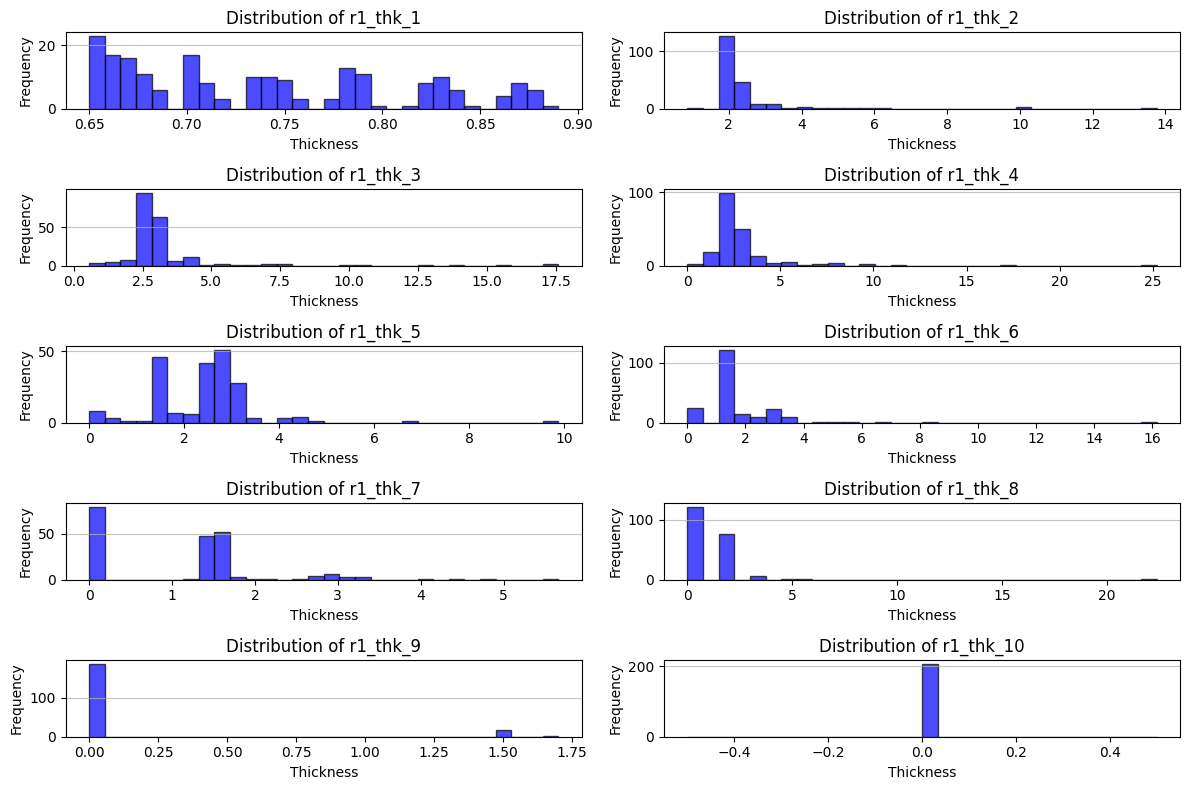

In [41]:
carline = 'c174'
direction = 'r1'



stiffnessMatrices[carline].filter(like=direction+"_thk")

#plot 10 distribution curves to check curve for each column
plt.figure(figsize=(12, 8))
for i in range(10):
        plt.subplot(5, 2, i + 1)   
        plt.hist(stiffnessMatrices[carline].filter(like=direction+"_thk").iloc[:, i], bins=30, alpha=0.7, color='blue', edgecolor='black')
        plt.title(f"Distribution of {direction}_thk_{i + 1}")
        plt.xlabel("Thickness")
        plt.ylabel("Frequency")
        plt.grid(axis='y', alpha=0.75)
        plt.tight_layout()
        

In [43]:
# lets filter rows which has thk_2 or thk_3 0
filtered_rows = stiffnessMatrices[carline].loc[
    (stiffnessMatrices[carline].filter(like=direction+"_thk").iloc[:, 3] == 0) |
    (stiffnessMatrices[carline].filter(like=direction+"_thk").iloc[:, 4] == 0)
]


filtered_rows

,x,y,z,r1_thk_1,r1_e_1,r1_pr_1,r1_dist_1,r1_thk_2,r1_e_2,r1_pr_2,...,r2_dist_8,r2_thk_9,r2_e_9,r2_pr_9,r2_dist_9,r2_thk_10,r2_e_10,r2_pr_10,r2_dist_10,a3ms
121,853.62,339.89,607.82,0.68,71.7,0.21,10.18,1.88,71.7,0.21,...,24.95,3.00,3.1,0.32,0.0,0.0,0.0,0.0,0.0,57.60
122,853.98,360.33,607.82,0.68,71.7,0.21,10.18,1.88,71.7,0.21,...,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,57.69
123,854.11,379.64,609.78,0.68,71.7,0.21,10.21,1.89,71.7,0.21,...,0.60,3.01,3.1,0.32,0.0,0.0,0.0,0.0,0.0,54.78
133,851.27,335.34,629.39,0.70,71.7,0.21,10.61,1.96,71.7,0.21,...,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,51.12
134,851.69,359.19,629.39,0.71,71.7,0.21,10.61,1.96,71.7,0.21,...,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,59.78
149,848.96,360.33,655.52,0.75,71.7,0.21,13.38,2.09,71.7,0.21,...,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,59.34
180,849.90,345.56,644.16,0.73,71.7,0.21,10.98,2.03,71.7,0.21,...,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,51.52
205,851.15,479.60,654.55,0.75,71.7,0.21,11.23,2.07,71.7,0.21,...,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,46.94
